<a href="https://colab.research.google.com/github/SvisTheCoder/Projet-Annuel-3e-ann-e/blob/prototype/Lin%C3%A9raire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import matplotlib.pyplot as plt

In [17]:
!pip install -q --upgrade google-cloud-storage

In [18]:
from google.colab import auth
auth.authenticate_user()

In [19]:
from google.cloud import storage

bucket_name = "dataset_batiments"
prefix_root = "Images de bâtiments/"

client = storage.Client()
bucket = client.bucket(bucket_name)

print("Connexion OK au bucket :", bucket_name)

Connexion OK au bucket : dataset_batiments


In [20]:
for i, blob in enumerate(client.list_blobs(bucket_name, prefix=prefix_root)):
    print(blob.name)
    if i >= 30:
        break

Images de bâtiments/Art déco/1275_800px-Esquina_Edificio_del_Arq._Virasoro_3.JPG
Images de bâtiments/Art déco/2051_450px-Vancouver_City_Hall__282012_29_-_02.JPG
Images de bâtiments/Art déco/3147_800px-Edificio_Guardiola_11.jpg
Images de bâtiments/Art déco/3177_Mexico_bellas_artes_palace.jpg
Images de bâtiments/Art déco/544_800px-Berrigan_Hotel_101.JPG
Images de bâtiments/Art nouveau/13_800px-Casa_Deutsch_-_Oradea.JPG
Images de bâtiments/Art nouveau/14_800px-WAK_Kaltennordheim_036.jpg
Images de bâtiments/Art nouveau/206_800px-P.S.K._Vienna_August_2006_031.jpg
Images de bâtiments/Art nouveau/35_800px-Caen_Gr_C3_A2ce_de_Dieu_bains_et_lavoirs.JPG
Images de bâtiments/Art nouveau/64_J_C4_ABd_C5_AB_Ji_C3_A0ot_C3_A1ng.jpg
Images de bâtiments/Gothique/02_0005.jpg
Images de bâtiments/Gothique/02_0007.jpg
Images de bâtiments/Gothique/02_0012.jpg
Images de bâtiments/Gothique/02_0014.jpg
Images de bâtiments/Gothique/02_0019.jpg


In [21]:
import os

remote_to_local = {
    "Art déco": "art_deco",
    "Art nouveau": "art_nouveau",
    "Gothique": "gothique"
}

local_root = "/content/dataset_batiments"
max_per_class = 20   # change si tu veux plus

os.makedirs(local_root, exist_ok=True)

for remote_class, local_class in remote_to_local.items():
    class_prefix = f"{prefix_root}{remote_class}/"
    class_dir = os.path.join(local_root, local_class)
    os.makedirs(class_dir, exist_ok=True)

    blobs = list(client.list_blobs(bucket_name, prefix=class_prefix))
    image_blobs = [
        blob for blob in blobs
        if blob.name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ][:max_per_class]

    print(f"{remote_class} -> {len(image_blobs)} fichiers")

    for blob in image_blobs:
        filename = os.path.basename(blob.name)
        local_path = os.path.join(class_dir, filename)
        blob.download_to_filename(local_path)

Art déco -> 5 fichiers
Art nouveau -> 5 fichiers
Gothique -> 5 fichiers


In [22]:
for local_class in remote_to_local.values():
    class_dir = os.path.join(local_root, local_class)
    print(local_class, len(os.listdir(class_dir)))

art_deco 5
art_nouveau 5
gothique 5


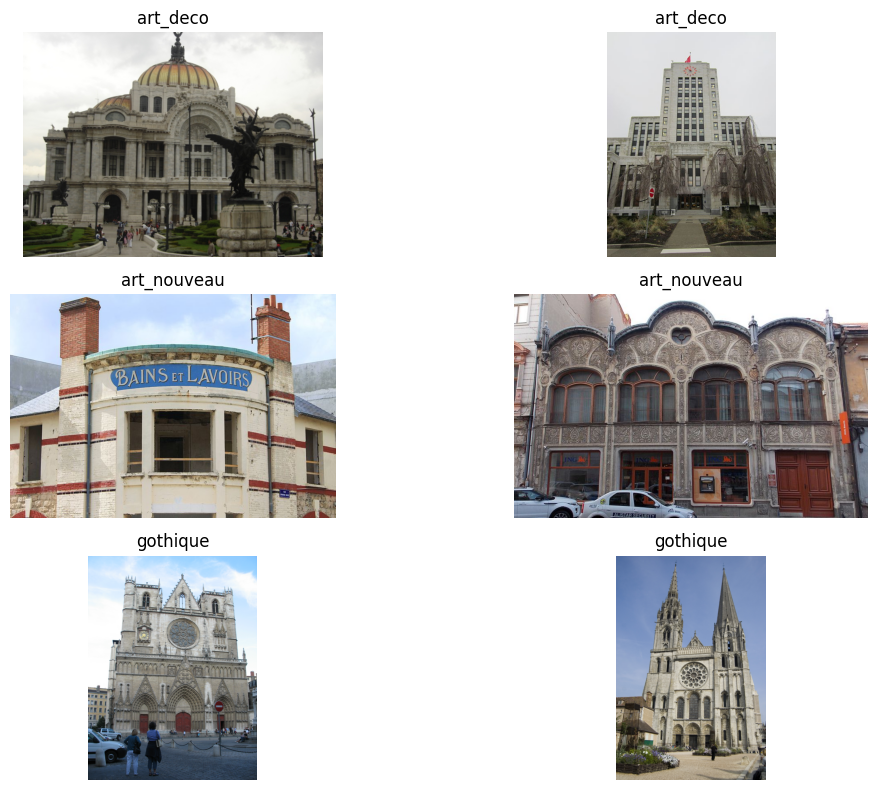

In [23]:
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(12, 8))
plot_index = 1

for local_class in remote_to_local.values():
    class_dir = os.path.join(local_root, local_class)
    files = os.listdir(class_dir)[:2]

    for file_name in files:
        img_path = os.path.join(class_dir, file_name)
        img = Image.open(img_path)

        plt.subplot(len(remote_to_local), 2, plot_index)
        plt.imshow(img)
        plt.title(local_class)
        plt.axis("off")
        plot_index += 1

plt.tight_layout()
plt.show()

In [24]:
import numpy as np
from PIL import Image

classes = ["art_deco", "art_nouveau", "gothique"]
dataset_path = "/content/dataset_batiments"

def load_images(dataset_path, classes, image_size=(64, 64), max_per_class=None):
    X = []
    y = []

    for class_index, class_name in enumerate(classes):
        class_dir = os.path.join(dataset_path, class_name)

        files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.webp'))]

        if max_per_class is not None:
            files = files[:max_per_class]

        print(f"{class_name} : {len(files)} images")

        for file_name in files:
            img_path = os.path.join(class_dir, file_name)
            img = Image.open(img_path).convert("L")   # niveaux de gris
            img = img.resize(image_size)
            img_array = np.array(img, dtype=np.float32) / 255.0
            X.append(img_array.flatten())
            y.append(class_index)

    return np.array(X), np.array(y)

X_images, y_images = load_images(dataset_path, classes, image_size=(64, 64), max_per_class=20)

print("Shape de X :", X_images.shape)
print("Shape de y :", y_images.shape)
print("Classes présentes :", np.unique(y_images))

art_deco : 5 images
art_nouveau : 5 images
gothique : 5 images
Shape de X : (15, 4096)
Shape de y : (15,)
Classes présentes : [0 1 2]


In [25]:
import os
import numpy as np
from PIL import Image

classes = ["art_deco", "art_nouveau", "gothique"]
dataset_path = "/content/dataset_batiments"

def load_images(dataset_path, classes, image_size=(64, 64), max_per_class=None):
    X = []
    y = []

    for class_index, class_name in enumerate(classes):
        class_dir = os.path.join(dataset_path, class_name)

        files = [f for f in os.listdir(class_dir)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.webp'))]

        if max_per_class is not None:
            files = files[:max_per_class]

        print(f"{class_name} : {len(files)} images")

        for file_name in files:
            img_path = os.path.join(class_dir, file_name)

            img = Image.open(img_path).convert("L")   # niveaux de gris
            img = img.resize(image_size)
            img_array = np.array(img, dtype=np.float32) / 255.0

            X.append(img_array.flatten())
            y.append(class_index)

    return np.array(X), np.array(y)

X_images, y_images = load_images(
    dataset_path,
    classes,
    image_size=(64, 64),
    max_per_class=20
)

print("Shape de X_images :", X_images.shape)
print("Shape de y_images :", y_images.shape)
print("Classes présentes :", np.unique(y_images))

art_deco : 5 images
art_nouveau : 5 images
gothique : 5 images
Shape de X_images : (15, 4096)
Shape de y_images : (15,)
Classes présentes : [0 1 2]


In [26]:
from collections import Counter

print("Répartition des classes :", Counter(y_images))
print("Longueur d'un vecteur image :", X_images.shape[1])
print("Premier label :", y_images[0])
print("Premières valeurs du premier vecteur :", X_images[0][:10])

Répartition des classes : Counter({np.int64(0): 5, np.int64(1): 5, np.int64(2): 5})
Longueur d'un vecteur image : 4096
Premier label : 0
Premières valeurs du premier vecteur : [0.9882353  0.9764706  0.9647059  0.9490196  0.93333334 0.92941177
 0.93333334 0.93333334 0.9372549  0.9411765 ]


1) Classification linéaire avec la règle de Rosenblatt

In [27]:
import numpy as np

# classes actuelles :
# 0 = art_deco
# 1 = art_nouveau
# 2 = gothique

mask = np.isin(y_images, [0, 2])

X_bin = X_images[mask]
y_bin_raw = y_images[mask]

# Conversion en labels {-1, +1}
y_bin = np.where(y_bin_raw == 0, -1, 1)

print("Shape de X_bin :", X_bin.shape)
print("Shape de y_bin :", y_bin.shape)
print("Labels uniques :", np.unique(y_bin))

Shape de X_bin : (10, 4096)
Shape de y_bin : (10,)
Labels uniques : [-1  1]


In [28]:
np.random.seed(42)

indices = np.random.permutation(len(X_bin))
X_bin = X_bin[indices]
y_bin = y_bin[indices]

split_index = int(0.8 * len(X_bin))

X_train = X_bin[:split_index]
y_train = y_bin[:split_index]

X_test = X_bin[split_index:]
y_test = y_bin[split_index:]

print("Train :", X_train.shape, y_train.shape)
print("Test  :", X_test.shape, y_test.shape)

Train : (8, 4096) (8,)
Test  : (2, 4096) (2,)


In [29]:
np.random.seed(42)

indices = np.random.permutation(len(X_bin))
X_bin = X_bin[indices]
y_bin = y_bin[indices]

split_index = int(0.8 * len(X_bin))

X_train = X_bin[:split_index]
y_train = y_bin[:split_index]

X_test = X_bin[split_index:]
y_test = y_bin[split_index:]

print("Train :", X_train.shape, y_train.shape)
print("Test  :", X_test.shape, y_test.shape)

Train : (8, 4096) (8,)
Test  : (2, 4096) (2,)


In [30]:
model_rosenblatt = RosenblattPerceptron(learning_rate=0.01, epochs=20)
model_rosenblatt.fit(X_train, y_train)

train_acc = model_rosenblatt.score(X_train, y_train)
test_acc = model_rosenblatt.score(X_test, y_test)

print("Accuracy train :", train_acc)
print("Accuracy test  :", test_acc)
print("Nombre de features :", X_train.shape[1])

Accuracy train : 1.0
Accuracy test  : 0.5
Nombre de features : 4096


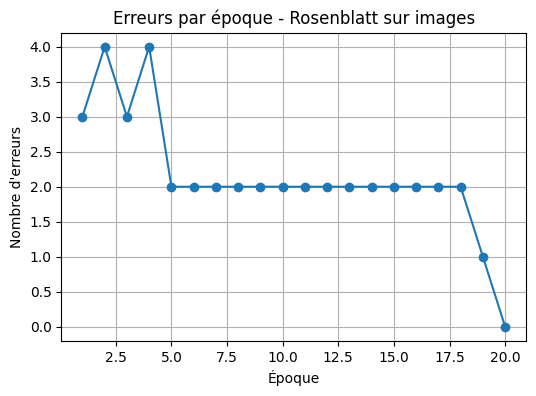

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(model_rosenblatt.errors_per_epoch) + 1),
         model_rosenblatt.errors_per_epoch,
         marker='o')
plt.title("Erreurs par époque - Rosenblatt sur images")
plt.xlabel("Époque")
plt.ylabel("Nombre d'erreurs")
plt.grid(True)
plt.show()

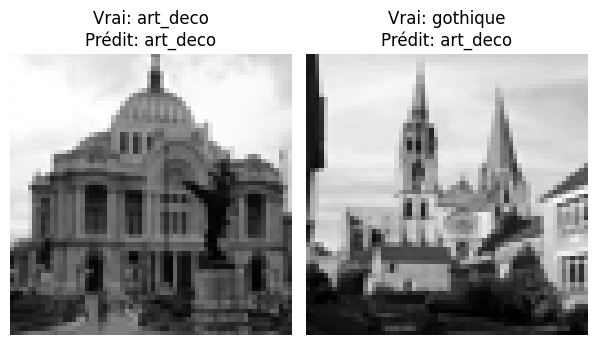

In [32]:
label_names = {-1: "art_deco", 1: "gothique"}

y_pred_test = model_rosenblatt.predict(X_test)

plt.figure(figsize=(12, 8))

n_show = min(8, len(X_test))

for i in range(n_show):
    img = X_test[i].reshape(64, 64)

    true_label = label_names[y_test[i]]
    pred_label = label_names[y_pred_test[i]]

    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Vrai: {true_label}\nPrédit: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

2) Modèle linéaire de régression avec la pseudo-inverse de Moore-Penrose

Poids [biais, coefficient] : [1.11785714 1.98214286]
Prédictions : [ 3.1         5.08214286  7.06428571  9.04642857 11.02857143 13.01071429
 14.99285714 16.975     ]
MSE : 0.01566964285714275


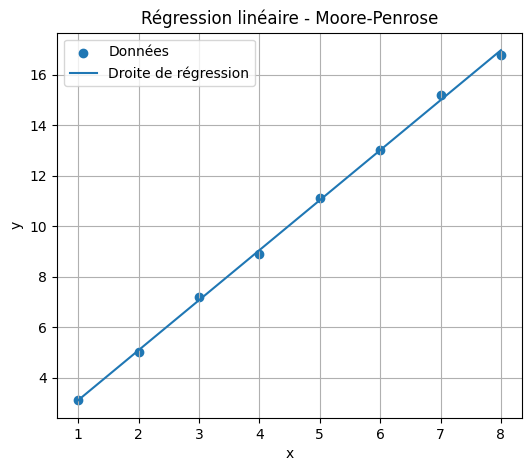

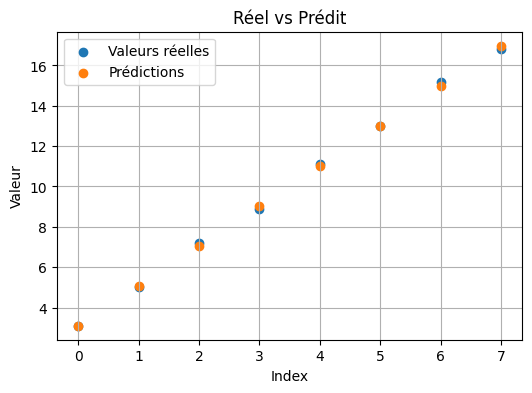

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Données de régression
# =========================
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8]], dtype=float)
y = np.array([3.1, 5.0, 7.2, 8.9, 11.1, 13.0, 15.2, 16.8], dtype=float)
# En gros proche de y = 2x + 1


# =========================
# Modèle Moore-Penrose
# =========================
class LinearRegressionMoorePenrose:
    def __init__(self):
        self.weights = None

    def fit(self, X, y):
        # Ajout du biais
        X_bias = np.c_[np.ones((X.shape[0], 1)), X]
        self.weights = np.linalg.pinv(X_bias) @ y

    def predict(self, X):
        X_bias = np.c_[np.ones((X.shape[0], 1)), X]
        return X_bias @ self.weights

    def mse(self, X, y):
        y_pred = self.predict(X)
        return np.mean((y - y_pred) ** 2)


# =========================
# Entraînement
# =========================
model = LinearRegressionMoorePenrose()
model.fit(X, y)

y_pred = model.predict(X)

print("Poids [biais, coefficient] :", model.weights)
print("Prédictions :", y_pred)
print("MSE :", model.mse(X, y))


# =========================
# Visualisation
# =========================
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], y, label="Données")

x_line = np.linspace(X[:, 0].min(), X[:, 0].max(), 200).reshape(-1, 1)
y_line = model.predict(x_line)

plt.plot(x_line, y_line, label="Droite de régression")
plt.title("Régression linéaire - Moore-Penrose")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# Comparaison vraie valeur / prédiction
# =========================
plt.figure(figsize=(6, 4))
plt.scatter(range(len(y)), y, label="Valeurs réelles")
plt.scatter(range(len(y_pred)), y_pred, label="Prédictions")
plt.title("Réel vs Prédit")
plt.xlabel("Index")
plt.ylabel("Valeur")
plt.legend()
plt.grid(True)
plt.show()

3) PMC avec SGD en classification binaire

Probabilités : [5.16926499e-04 1.65267510e-03 1.61107661e-03 5.12625365e-04
 9.98991558e-01 9.99318490e-01 9.99316054e-01 9.98981429e-01]
Prédictions : [0 0 0 0 1 1 1 1]
Accuracy : 1.0


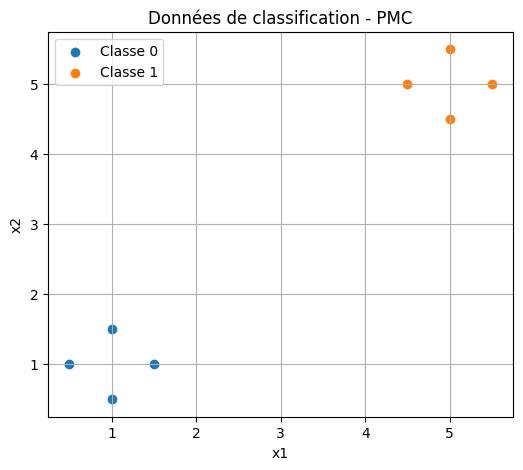

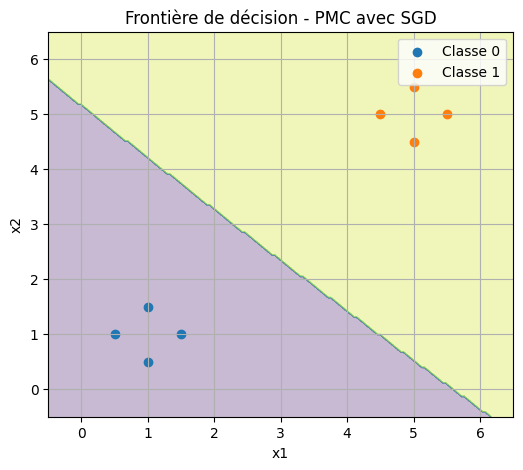

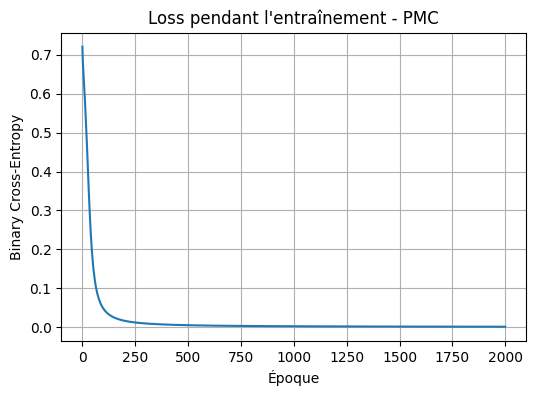

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Données de classification
# =========================
X = np.array([
    [0.5, 1.0],
    [1.0, 1.5],
    [1.5, 1.0],
    [1.0, 0.5],
    [4.5, 5.0],
    [5.0, 5.5],
    [5.5, 5.0],
    [5.0, 4.5]
], dtype=float)

# Labels en {0, 1}
y = np.array([0, 0, 0, 0, 1, 1, 1, 1])


# =========================
# PMC (MLP) avec SGD
# =========================
class MLPBinaryClassifier:
    def __init__(self, input_size, hidden_size, learning_rate=0.1, epochs=2000):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.learning_rate = learning_rate
        self.epochs = epochs

        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, 1) * 0.5
        self.b2 = np.zeros((1, 1))

        self.loss_history = []

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, a):
        return a * (1 - a)

    def binary_cross_entropy(self, y_true, y_pred):
        eps = 1e-12
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = self.sigmoid(z1)

        z2 = a1 @ self.W2 + self.b2
        a2 = self.sigmoid(z2)

        return z1, a1, z2, a2

    def fit(self, X, y):
        y = y.reshape(-1, 1)

        for epoch in range(self.epochs):
            indices = np.random.permutation(X.shape[0])
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for i in range(X.shape[0]):
                xi = X_shuffled[i:i+1]
                yi = y_shuffled[i:i+1]

                # Forward
                z1, a1, z2, a2 = self.forward(xi)

                # Backprop
                error_output = a2 - yi
                dW2 = a1.T @ error_output
                db2 = error_output

                error_hidden = (error_output @ self.W2.T) * self.sigmoid_derivative(a1)
                dW1 = xi.T @ error_hidden
                db1 = error_hidden

                # Mise à jour SGD
                self.W2 -= self.learning_rate * dW2
                self.b2 -= self.learning_rate * db2
                self.W1 -= self.learning_rate * dW1
                self.b1 -= self.learning_rate * db1

            # Calcul de la loss sur tout le dataset
            _, _, _, y_pred_all = self.forward(X)
            loss = self.binary_cross_entropy(y, y_pred_all)
            self.loss_history.append(loss)

    def predict_proba(self, X):
        _, _, _, a2 = self.forward(X)
        return a2

    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba >= 0.5).astype(int).flatten()

    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)


# =========================
# Entraînement
# =========================
np.random.seed(42)
model = MLPBinaryClassifier(input_size=2, hidden_size=4, learning_rate=0.1, epochs=2000)
model.fit(X, y)

print("Probabilités :", model.predict_proba(X).flatten())
print("Prédictions :", model.predict(X))
print("Accuracy :", model.score(X, y))


# =========================
# Visualisation des points
# =========================
plt.figure(figsize=(6, 5))
for label in np.unique(y):
    plt.scatter(X[y == label, 0], X[y == label, 1], label=f"Classe {label}")

plt.title("Données de classification - PMC")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# Visualisation de la frontière
# =========================
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.3)

for label in np.unique(y):
    plt.scatter(X[y == label, 0], X[y == label, 1], label=f"Classe {label}")

plt.title("Frontière de décision - PMC avec SGD")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# Visualisation de la loss
# =========================
plt.figure(figsize=(6, 4))
plt.plot(model.loss_history)
plt.title("Loss pendant l'entraînement - PMC")
plt.xlabel("Époque")
plt.ylabel("Binary Cross-Entropy")
plt.grid(True)
plt.show()